In [1]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes

# Load dataset
X, y = load_diabetes(return_X_y=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Elastic Net model
model = ElasticNet(alpha=0.1, l1_ratio=0.5)

# Train the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("Coefficients:", model.coef_)

Coefficients: [ 1.08309211e+01 -9.51378929e-03  3.89068647e+01  2.87792332e+01
  1.03720066e+01  7.19189161e+00 -2.35109789e+01  2.56271600e+01
  3.50737451e+01  2.40712511e+01]


Plain Linear Regression:
Coefficients: [ 1.52710641 -1.93224448 -0.01064705  0.08037361  2.99638427]
Intercept: -0.07306236831451823
Train MSE: 0.2008309964535892

Ridge Regression (alpha=1.0):
Coefficients: [ 1.50700617 -1.91337163 -0.0106447   0.07746111  2.96727158]
Intercept: -0.07597844035385554
Train MSE: 0.2023611251562728

Lasso Regression (alpha=0.1):
Coefficients: [ 1.39389613 -1.8395825  -0.          0.          2.89055553]
Intercept: -0.07826978806709861
Train MSE: 0.23895503595198897

Elastic Net (alpha=0.1, l1_ratio=0.5):
Coefficients: [ 1.36679019 -1.79711189 -0.          0.00826611  2.80606761]
Intercept: -0.0865302239954771
Train MSE: 0.2786732480414378



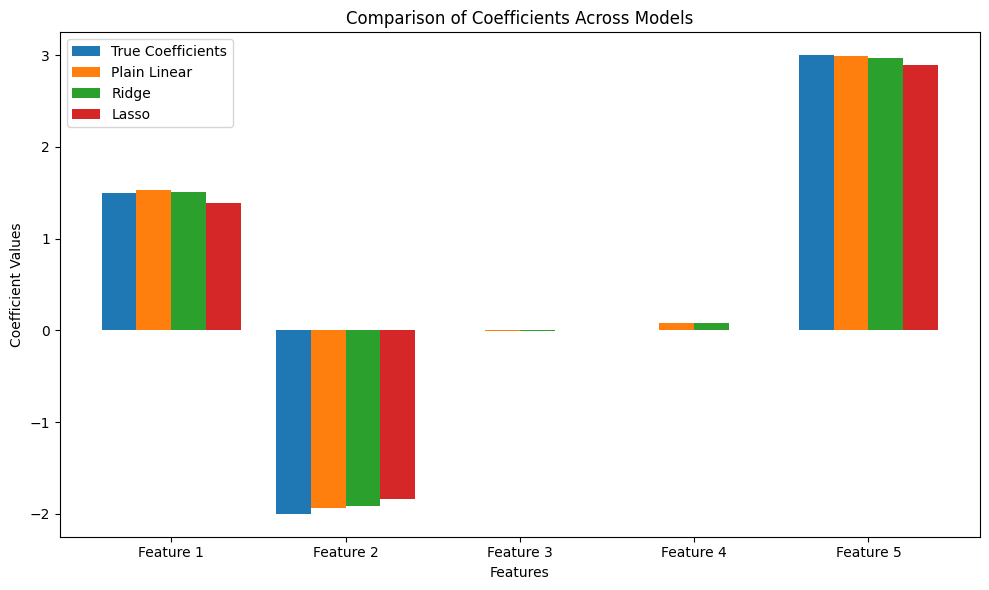

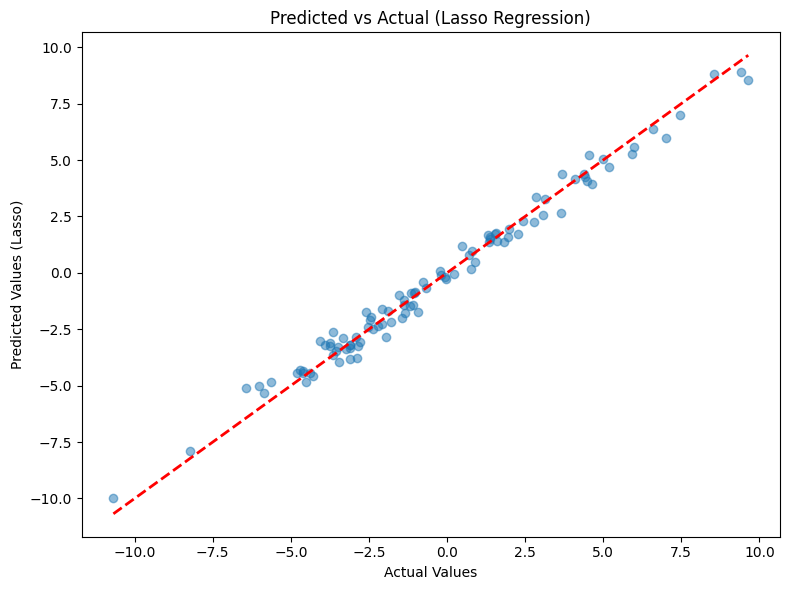

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

# Step 1: Generate Synthetic Data
np.random.seed(42)  # For reproducibility
n_samples = 100
n_features = 5

X = np.random.randn(n_samples, n_features)
true_weights = np.array([1.5, -2.0, 0.0, 0.0, 3.0])
y = X @ true_weights + np.random.randn(n_samples) * 0.5  # Add noise

# Step 2: Fit Plain Linear Regression (No Regularization)
plain_model = LinearRegression()
plain_model.fit(X, y)

plain_pred = plain_model.predict(X)
plain_mse = mean_squared_error(y, plain_pred)

print("Plain Linear Regression:")
print("Coefficients:", plain_model.coef_)
print("Intercept:", plain_model.intercept_)
print("Train MSE:", plain_mse)
print()

# Step 3: Fit Ridge Regression (L2 Penalty)
ridge_model = Ridge(alpha=1.0)  # alpha = regularization strength
ridge_model.fit(X, y)

ridge_pred = ridge_model.predict(X)
ridge_mse = mean_squared_error(y, ridge_pred)

print("Ridge Regression (alpha=1.0):")
print("Coefficients:", ridge_model.coef_)
print("Intercept:", ridge_model.intercept_)
print("Train MSE:", ridge_mse)
print()

# Step 4: Fit Lasso Regression (L1 Penalty)
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X, y)

lasso_pred = lasso_model.predict(X)
lasso_mse = mean_squared_error(y, lasso_pred)

print("Lasso Regression (alpha=0.1):")
print("Coefficients:", lasso_model.coef_)
print("Intercept:", lasso_model.intercept_)
print("Train MSE:", lasso_mse)
print()

# Step 5: Fit Elastic Net (Combination of L1 and L2)
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)  # alpha=strength, l1_ratio=balance (0.5 = equal mix)
elastic_model.fit(X, y)

elastic_pred = elastic_model.predict(X)
elastic_mse = mean_squared_error(y, elastic_pred)

print("Elastic Net (alpha=0.1, l1_ratio=0.5):")
print("Coefficients:", elastic_model.coef_)
print("Intercept:", elastic_model.intercept_)
print("Train MSE:", elastic_mse)
print()

# Step 6: Visualization - Bar Plot of Coefficients for Comparison
features = [f'Feature {i+1}' for i in range(n_features)]
width = 0.2  # Bar width

fig, ax = plt.subplots(figsize=(10, 6))

# Positions for bars
x = np.arange(len(features))

# Plot bars for each model
ax.bar(x - 1.5*width, true_weights, width, label='True Coefficients')
ax.bar(x - 0.5*width, plain_model.coef_, width, label='Plain Linear')
ax.bar(x + 0.5*width, ridge_model.coef_, width, label='Ridge')
ax.bar(x + 1.5*width, lasso_model.coef_, width, label='Lasso')

ax.set_xlabel('Features')
ax.set_ylabel('Coefficient Values')
ax.set_title('Comparison of Coefficients Across Models')
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.legend()

plt.tight_layout()
plt.show()

# Optional: Additional Visualization - Predicted vs Actual for Lasso (as an example)
plt.figure(figsize=(8, 6))
plt.scatter(y, lasso_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values (Lasso)')
plt.title('Predicted vs Actual (Lasso Regression)')
plt.tight_layout()
plt.show()

Dataset created with 506 samples and 8 features.
Target: House Price (in $10,000s)

First 5 rows:
       CRIM        RM       DIS       RAD       TAX   PTRATIO         B  \
0  0.496714 -0.138264  0.647689  1.523030 -0.234153 -0.234137  1.579213   
1 -0.469474  0.542560 -0.463418 -0.465730  0.241962 -1.913280 -1.724918   
2 -1.012831  0.314247 -0.908024 -1.412304  1.465649 -0.225776  0.067528   
3 -0.544383  0.110923 -1.150994  0.375698 -0.600639 -0.291694 -0.601707   
4 -0.013497 -1.057711  0.822545 -1.220844  0.208864 -1.959670 -1.328186   

      LSTAT     PRICE  
0  0.767435  5.000000  
1 -0.562288  5.095067  
2 -1.424748  5.529478  
3  1.852278  5.000000  
4  0.196861  5.000000  

Dataset description:
             CRIM          RM         DIS         RAD         TAX     PTRATIO  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    -0.013712    0.034359   -0.056652    0.043367    0.073065    0.011626   
std      0.994439    1.022399    0.978271 

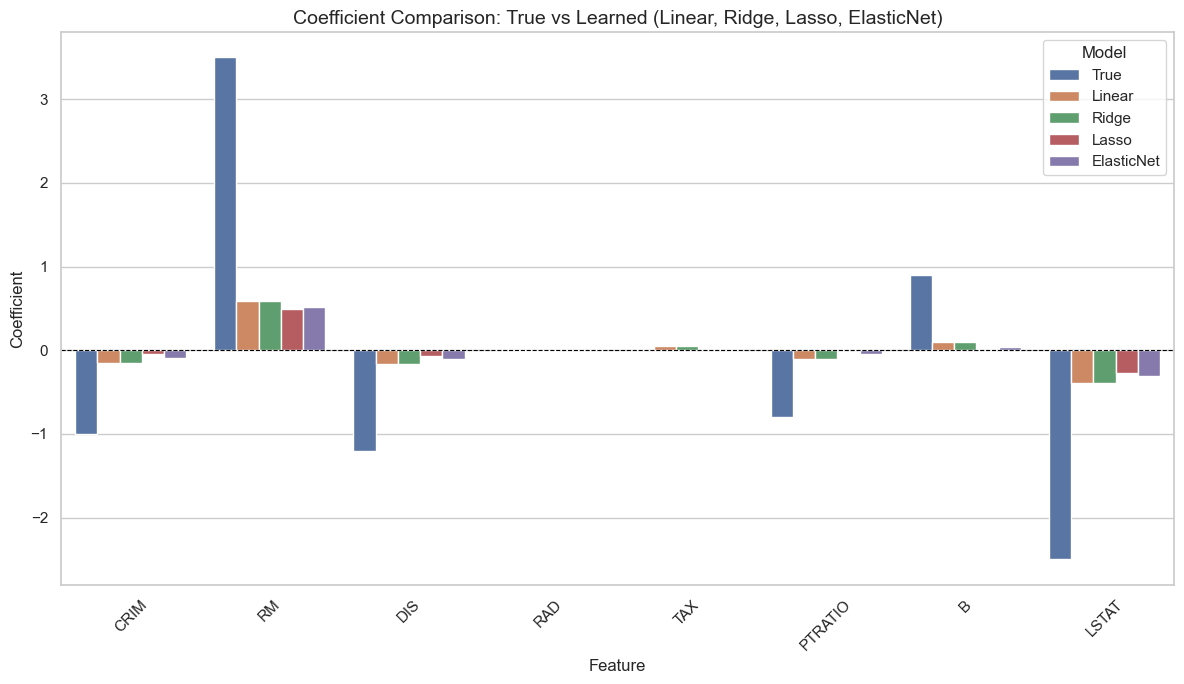

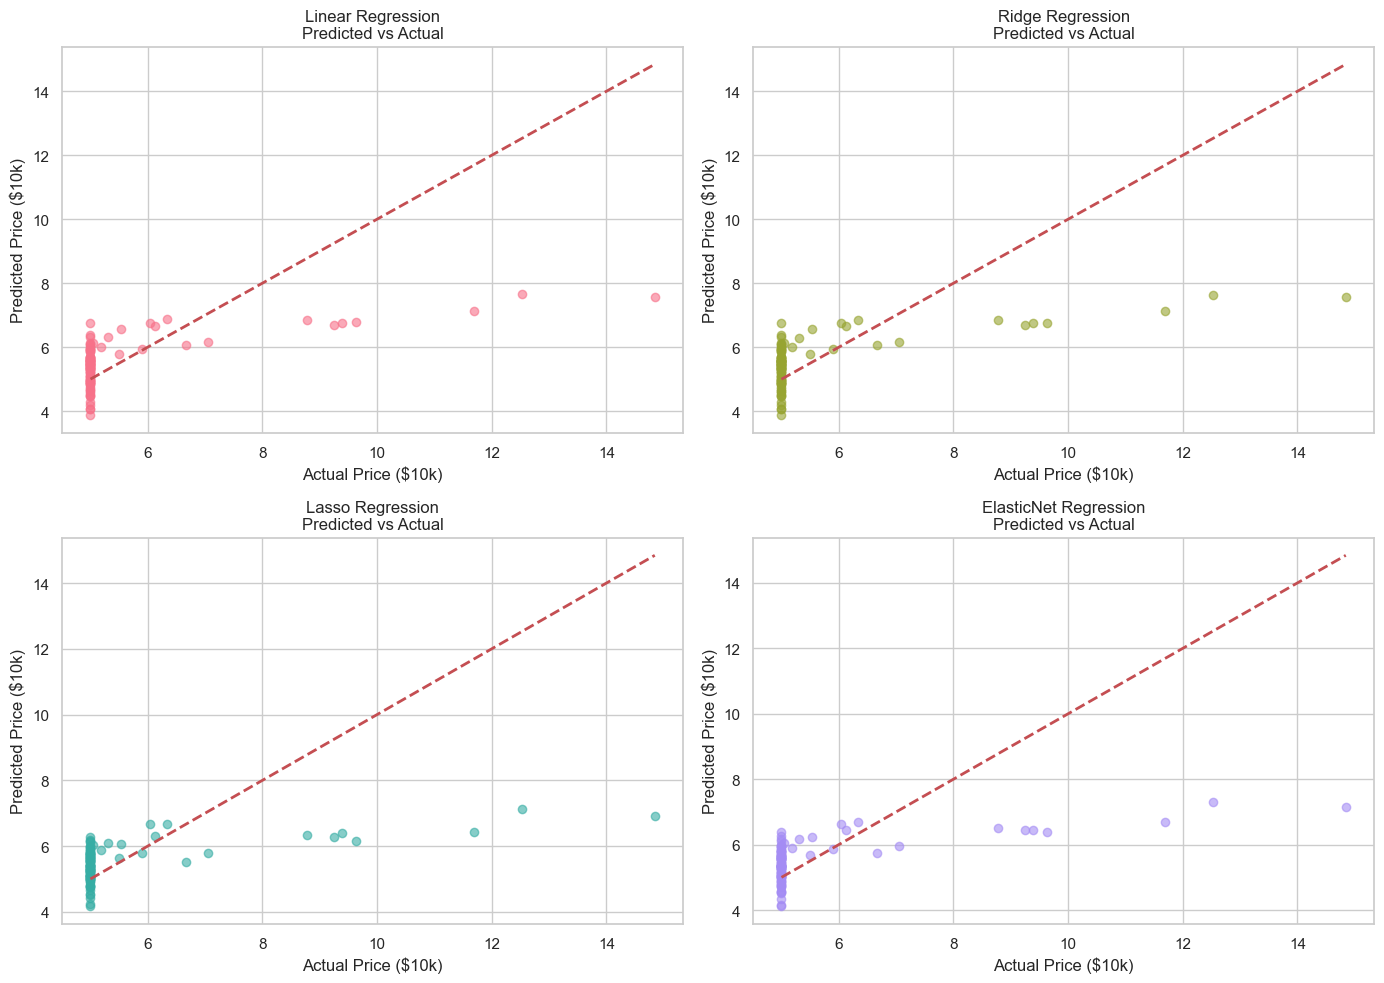

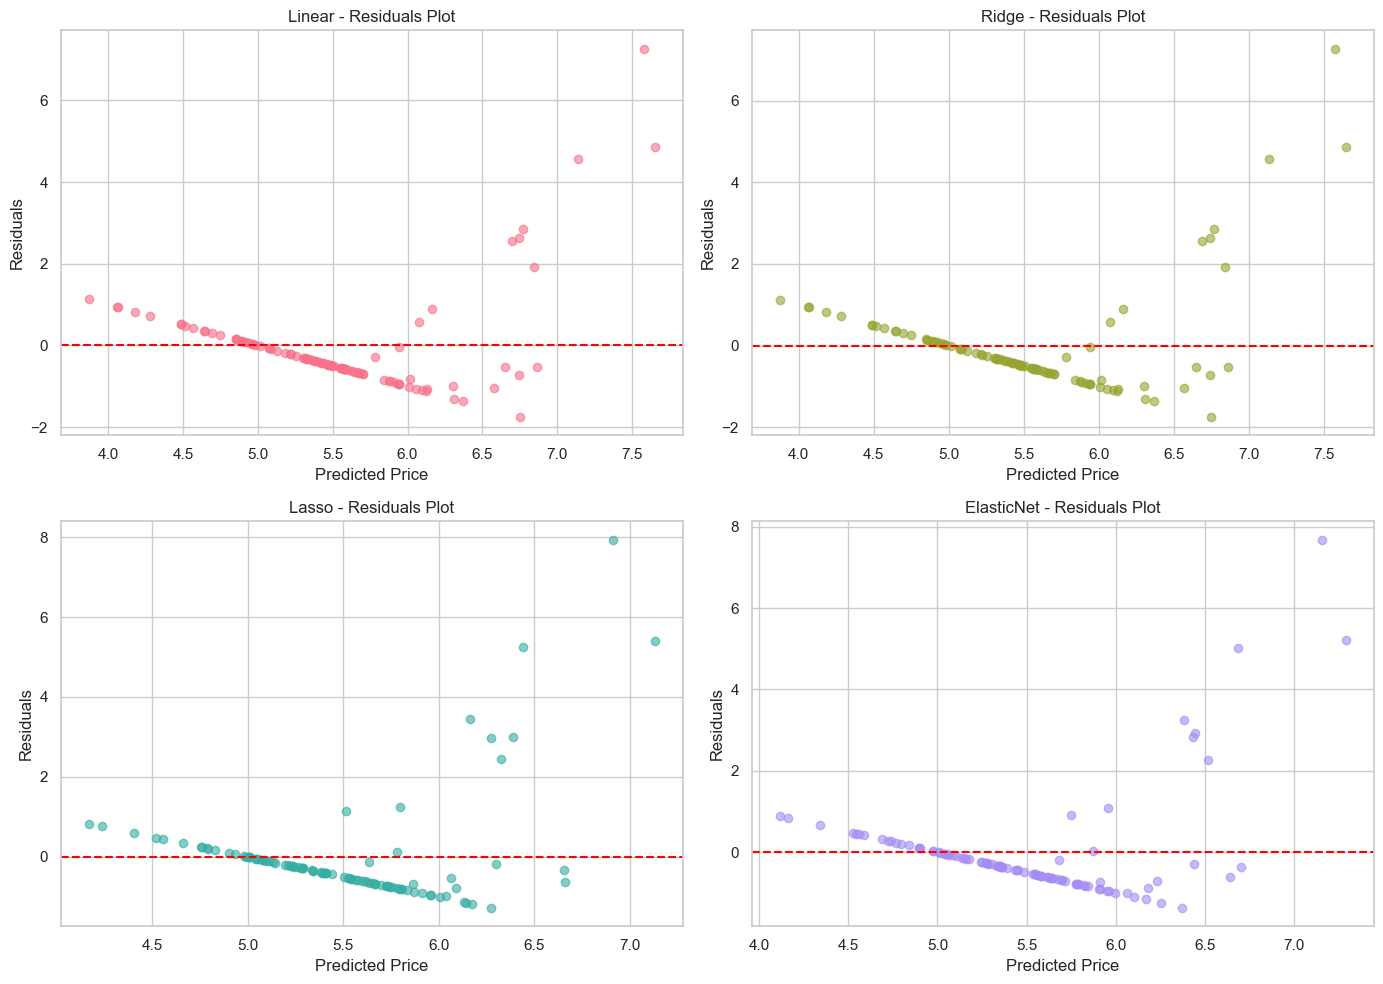


Key Observations:
- Lasso sets some irrelevant coefficients (RAD, TAX) close to zero → feature selection
- Ridge shrinks all coefficients but keeps them non-zero
- ElasticNet combines both: some zeros + overall shrinkage
- All regularized models help prevent overfitting (compare Train vs Test MSE)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Set style for better plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Step 1: Create a Real-World-Like Dataset (Boston Housing Prices)
# We'll use a simple, built-in-like dataset: predict house price based on features
# For demonstration, we'll create a synthetic but realistic dataset inspired by Boston Housing

np.random.seed(42)

n_samples = 506  # Classic Boston size
n_features = 8

# Feature names (realistic)
feature_names = [
    'CRIM',    # crime rate
    'RM',      # average rooms per dwelling
    'DIS',     # distance to employment centers
    'RAD',     # accessibility to highways
    'TAX',     # tax rate
    'PTRATIO', # pupil-teacher ratio
    'B',       # proportion of Black residents
    'LSTAT'    # % lower status population
]

# Generate realistic synthetic data
X = np.random.randn(n_samples, n_features)

# True coefficients (only some features really matter)
true_coef = np.array([ -1.0,  3.5, -1.2,  0.0,  0.0, -0.8,  0.9, -2.5 ])

# Generate target: house price (in $10,000s)
y = X @ true_coef + np.random.normal(0, 2, n_samples)
y = np.clip(y, 5, 50)  # Realistic price range

# Convert to DataFrame for better visualization
df = pd.DataFrame(X, columns=feature_names)
df['PRICE'] = y

print("Dataset created with 506 samples and 8 features.")
print("Target: House Price (in $10,000s)")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset description:")
print(df.describe())

# Step 2: Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Fit Models
models = {}
predictions = {}

# Plain Linear Regression
models['Linear'] = LinearRegression()
models['Linear'].fit(X_train, y_train)

# Ridge (L2)
models['Ridge'] = Ridge(alpha=1.0)
models['Ridge'].fit(X_train, y_train)

# Lasso (L1)
models['Lasso'] = Lasso(alpha=0.1)
models['Lasso'].fit(X_train, y_train)

# Elastic Net
models['ElasticNet'] = ElasticNet(alpha=0.1, l1_ratio=0.5)
models['ElasticNet'].fit(X_train, y_train)

# Step 4: Evaluate on Test Set
print("\n" + "="*60)
print("MODEL PERFORMANCE ON TEST DATA")
print("="*60)

results = []
for name, model in models.items():
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, pred_train)
    test_mse = mean_squared_error(y_test, pred_test)
    
    results.append({
        'Model': name,
        'Train MSE': round(train_mse, 3),
        'Test MSE': round(test_mse, 3),
        'Coefficients': model.coef_
    })
    
    print(f"{name:12} | Train MSE: {train_mse:.3f} | Test MSE: {test_mse:.3f}")

# Step 5: Visualization 1 - Coefficient Comparison
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'True': true_coef,
    'Linear': models['Linear'].coef_,
    'Ridge': models['Ridge'].coef_,
    'Lasso': models['Lasso'].coef_,
    'ElasticNet': models['ElasticNet'].coef_
})

plt.figure(figsize=(12, 7))
coef_melted = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')
sns.barplot(data=coef_melted, x='Feature', y='Coefficient', hue='Model')

plt.title('Coefficient Comparison: True vs Learned (Linear, Ridge, Lasso, ElasticNet)', fontsize=14)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

# Step 6: Visualization 2 - Predicted vs Actual (on Test Set)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    pred = model.predict(X_test)
    axes[idx].scatter(y_test, pred, alpha=0.6, color=sns.color_palette("husl", 4)[idx])
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[idx].set_xlabel('Actual Price ($10k)')
    axes[idx].set_ylabel('Predicted Price ($10k)')
    axes[idx].set_title(f'{name} Regression\nPredicted vs Actual')

plt.tight_layout()
plt.show()

# Step 7: Visualization 3 - Residuals Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    pred = model.predict(X_test)
    residuals = y_test - pred
    axes[idx].scatter(pred, residuals, alpha=0.6, color=sns.color_palette("husl", 4)[idx])
    axes[idx].axhline(0, color='red', linestyle='--')
    axes[idx].set_xlabel('Predicted Price')
    axes[idx].set_ylabel('Residuals')
    axes[idx].set_title(f'{name} - Residuals Plot')

plt.tight_layout()
plt.show()

# Final Summary
print("\nKey Observations:")
print("- Lasso sets some irrelevant coefficients (RAD, TAX) close to zero → feature selection")
print("- Ridge shrinks all coefficients but keeps them non-zero")
print("- ElasticNet combines both: some zeros + overall shrinkage")
print("- All regularized models help prevent overfitting (compare Train vs Test MSE)")